Cell 1 — Setup aur Snowflake se data pull karo:

In [1]:
import os
import pandas as pd
import numpy as np
import snowflake.connector
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

if "notebooks" in os.getcwd():
    os.chdir("..")

con = snowflake.connector.connect(
    user="Ruchita", password="RuchitaUday@0915", account="ZGQUOVJ-WT53494",
    warehouse="COMPUTE_WH", database="RETAILPULSE_DB", schema="ANALYTICS"
)
cur = con.cursor()

monthly_sql = """
SELECT 
    DATE_TRUNC('MONTH', order_purchase_timestamp) AS month_start,
    SUM(price) AS revenue
FROM fct_orders
WHERE order_status = 'delivered'
GROUP BY month_start
ORDER BY month_start
"""

monthly_df = cur.execute(monthly_sql).fetch_pandas_all()
monthly_df.columns = monthly_df.columns.str.lower()
con.close()

monthly_df["month_start"] = pd.to_datetime(monthly_df["month_start"])
# Sep-Dec 2016 ka ramp-up period exclude kar rahe hain — same reasoning jo
# humne Query 2 mein dekha tha, itna early data trend ko distort karta hai
monthly_df = monthly_df[monthly_df["month_start"] >= "2017-01-01"].reset_index(drop=True)

print(f"Training on {len(monthly_df)} months")
monthly_df.tail()

Training on 20 months


,month_start,revenue
15,2018-04-01,973534.09
16,2018-05-01,977544.69
17,2018-06-01,856077.86
18,2018-07-01,867953.46
19,2018-08-01,838576.64


Cell 2 — Feature Engineering:

In [2]:
# scikit-learn ko "dates" ka koi sense nahi hota — yeh sirf numbers samajhta hai.
# Toh humein manually trend aur seasonality signals banane padenge,
# jo Prophet/Holt-Winters automatically calculate kar lete.

monthly_df["t"] = np.arange(len(monthly_df))          # 0, 1, 2, 3... -> TREND capture karta hai
monthly_df["month_num"] = monthly_df["month_start"].dt.month  # 1-12 -> raw calendar month

# Cyclical encoding: "month" ko do smooth waves (sine aur cosine) mein convert karta hai
# Kyun: ek plain month number (1-12) model ko confuse karta hai — December (12) 
# aur January (1) ko bahut door samajhta hai, jabki actually yeh yearly cycle mein 
# adjacent hain. Sine/cosine encoding months ko ek circle ke around points jaisa 
# correctly represent karta hai.
monthly_df["month_sin"] = np.sin(2 * np.pi * monthly_df["month_num"] / 12)
monthly_df["month_cos"] = np.cos(2 * np.pi * monthly_df["month_num"] / 12)

features = ["t", "month_sin", "month_cos"]
X = monthly_df[features]
y = monthly_df["revenue"]

monthly_df.head()

,month_start,revenue,t,month_num,month_sin,month_cos
0,2017-01-01,111798.36,0,1,0.500000,8.660254e-01
1,2017-02-01,234223.40,1,2,0.866025,5.000000e-01
2,2017-03-01,359198.85,2,3,1.000000,6.123234e-17
3,2017-04-01,340669.68,3,4,0.866025,-5.000000e-01
4,2017-05-01,489338.25,4,5,0.500000,-8.660254e-01


Cell 3 — Model train karo aur 3 mahine aage forecast karo:

In [3]:
model = LinearRegression()
model.fit(X, y)

# Agle 3 mahino ke liye feature rows banao
last_t = monthly_df["t"].max()
last_date = monthly_df["month_start"].max()

future_rows = []
for i in range(1, 4):
    future_date = last_date + pd.DateOffset(months=i)
    future_rows.append({
        "month_start": future_date,
        "t": last_t + i,
        "month_num": future_date.month,
        "month_sin": np.sin(2 * np.pi * future_date.month / 12),
        "month_cos": np.cos(2 * np.pi * future_date.month / 12)
    })

future_df = pd.DataFrame(future_rows)
future_df["predicted_revenue"] = model.predict(future_df[features])

print("Forecast for next 3 months:")
print(future_df[["month_start", "predicted_revenue"]])

Forecast for next 3 months:
  month_start  predicted_revenue
0  2018-09-01       1.099896e+06
1  2018-10-01       1.177456e+06
2  2018-11-01       1.252709e+06


Cell 4 — Forecast ko chart pe visualize karo:

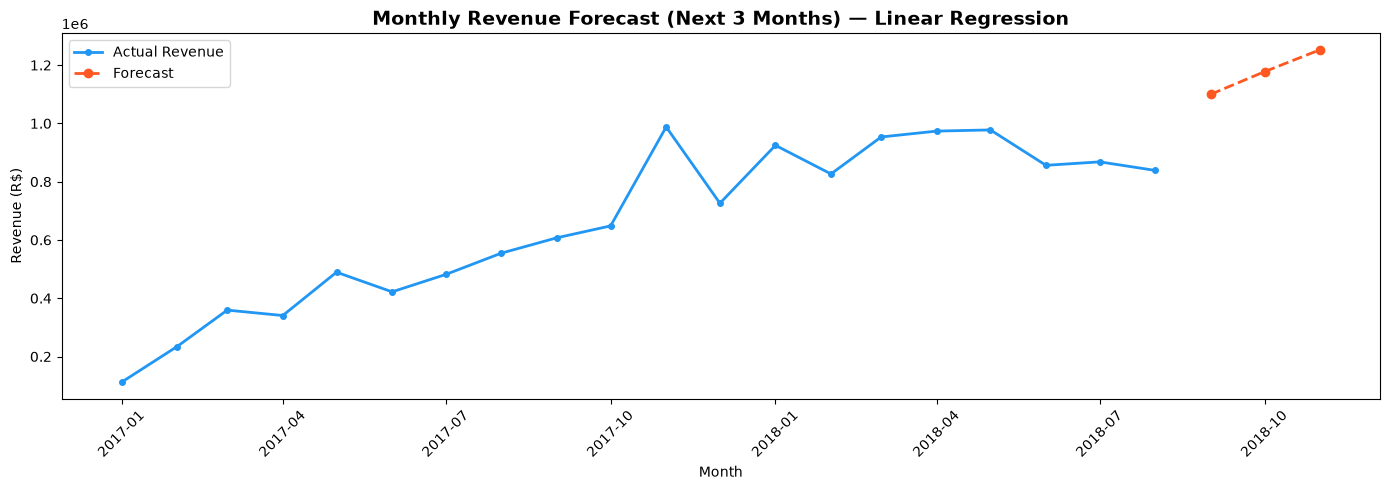

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_df["month_start"], monthly_df["revenue"], 
        label="Actual Revenue", color="#2196F3", linewidth=2, marker="o", markersize=4)
ax.plot(future_df["month_start"], future_df["predicted_revenue"], 
        label="Forecast", color="#FF5722", linewidth=2, linestyle="--", marker="o")

ax.set_title("Monthly Revenue Forecast (Next 3 Months) — Linear Regression", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (R$)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

os.makedirs("screenshots", exist_ok=True)
plt.savefig("screenshots/06_revenue_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

Cell 5 — Accuracy check karo (MAE, RMSE, MAPE) — last cell:

In [5]:
# Last 3 known months ko hold back karte hain testing ke liye
train_df = monthly_df.iloc[:-3]
test_df = monthly_df.iloc[-3:]

eval_model = LinearRegression()
eval_model.fit(train_df[features], train_df["revenue"])

predicted = eval_model.predict(test_df[features])
actual = test_df["revenue"].values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  $292,374.57
RMSE: $298,694.55
MAPE: 34.31%


MAE — average kitna off the predictions, Reais mein (sabse easy samajhne wala)
RMSE — same concept, lekin bade misses ko zyada penalize karta hai
MAPE — percentage mein kitna off the

In [6]:
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas

con = snowflake.connector.connect(
    user="Ruchita", password="RuchitaUday@0915", account="ZGQUOVJ-WT53494",
    warehouse="COMPUTE_WH", database="RETAILPULSE_DB", schema="ANALYTICS"
)
cur = con.cursor()

# Actual historical data, ek "type" column ke saath taaki Power BI mein
# actual aur forecast ko ek hi chart mein alag rang se dikha sakein
actual_part = monthly_df.reset_index()[["month_start", "revenue"]].copy()
actual_part.columns = ["MONTH_START", "REVENUE"]
actual_part["TYPE"] = "Actual"
actual_part["PREDICTED_REVENUE"] = None

forecast_part = future_df[["month_start", "predicted_revenue"]].copy()
forecast_part.columns = ["MONTH_START", "PREDICTED_REVENUE"]
forecast_part["TYPE"] = "Forecast"
forecast_part["REVENUE"] = None

combined = pd.concat([actual_part, forecast_part], ignore_index=True)
combined["MONTH_START"] = pd.to_datetime(combined["MONTH_START"])

cur.execute("""
CREATE OR REPLACE TABLE forecast_results (
    MONTH_START TIMESTAMP_NTZ,
    REVENUE FLOAT,
    PREDICTED_REVENUE FLOAT,
    TYPE VARCHAR(20)
)
""")

success, _, nrows, _ = write_pandas(con, combined, "FORECAST_RESULTS")
print(f"forecast_results loaded: {nrows} rows | success={success}")

con.close()

forecast_results loaded: 23 rows | success=True


In [7]:
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas

con = snowflake.connector.connect(
    user="Ruchita", password="RuchitaUday@0915", account="ZGQUOVJ-WT53494",
    warehouse="COMPUTE_WH", database="RETAILPULSE_DB", schema="ANALYTICS"
)
cur = con.cursor()

actual_part = monthly_df.reset_index()[["month_start", "revenue"]].copy()
actual_part.columns = ["MONTH_START", "REVENUE"]
actual_part["TYPE"] = "Actual"
actual_part["PREDICTED_REVENUE"] = None

forecast_part = future_df[["month_start", "predicted_revenue"]].copy()
forecast_part.columns = ["MONTH_START", "PREDICTED_REVENUE"]
forecast_part["TYPE"] = "Forecast"
forecast_part["REVENUE"] = None

combined = pd.concat([actual_part, forecast_part], ignore_index=True)

# FIX: date ko plain text string ke roop mein rakho, TIMESTAMP convert mat karo
combined["MONTH_START"] = pd.to_datetime(combined["MONTH_START"]).dt.strftime("%Y-%m-%d")

# Sanity check - yeh print karke confirm karo dates sahi hain BEFORE Snowflake mein bhejna
print(combined[["MONTH_START", "TYPE"]])

cur.execute("DROP TABLE IF EXISTS forecast_results")
cur.execute("""
CREATE OR REPLACE TABLE forecast_results (
    MONTH_START VARCHAR(20),
    REVENUE FLOAT,
    PREDICTED_REVENUE FLOAT,
    TYPE VARCHAR(20)
)
""")

success, _, nrows, _ = write_pandas(con, combined, "FORECAST_RESULTS")
print(f"forecast_results loaded: {nrows} rows | success={success}")

# Immediately verify
check = cur.execute("SELECT MONTH_START, TYPE FROM forecast_results ORDER BY MONTH_START").fetchall()
for row in check:
    print(row)

con.close()

   MONTH_START      TYPE
0   2017-01-01    Actual
1   2017-02-01    Actual
2   2017-03-01    Actual
3   2017-04-01    Actual
4   2017-05-01    Actual
5   2017-06-01    Actual
6   2017-07-01    Actual
7   2017-08-01    Actual
8   2017-09-01    Actual
9   2017-10-01    Actual
10  2017-11-01    Actual
11  2017-12-01    Actual
12  2018-01-01    Actual
13  2018-02-01    Actual
14  2018-03-01    Actual
15  2018-04-01    Actual
16  2018-05-01    Actual
17  2018-06-01    Actual
18  2018-07-01    Actual
19  2018-08-01    Actual
20  2018-09-01  Forecast
21  2018-10-01  Forecast
22  2018-11-01  Forecast
forecast_results loaded: 23 rows | success=True
('2017-01-01', 'Actual')
('2017-02-01', 'Actual')
('2017-03-01', 'Actual')
('2017-04-01', 'Actual')
('2017-05-01', 'Actual')
('2017-06-01', 'Actual')
('2017-07-01', 'Actual')
('2017-08-01', 'Actual')
('2017-09-01', 'Actual')
('2017-10-01', 'Actual')
('2017-11-01', 'Actual')
('2017-12-01', 'Actual')
('2018-01-01', 'Actual')
('2018-02-01', 'Actual')
('